In [3]:
import numpy as np

import matplotlib.pyplot as plt
N =955

xs = np.linspace(0, 1, N)



In [5]:
np.diff(xs)[0]

0.0010482180293501049

In [6]:
1 / (N - 1)

0.0010482180293501049

In [41]:
tau0 = 2

tau1 = -500

prob_state0 = 0
tj = prob_state0

threshold_type = 0.75

def alpha(tau0, tau1, tj):
    a = tau1 - tj * (tau0 + tau1)
    return a


tj = 0.6
#tau0 = 10
N = 100

alphas = np.zeros(N)
for i, tau1 in enumerate(np.linspace(0, 100, N)):
    tau0 = tau1
    alphas[i] = alpha(tau0, tau1, tj)

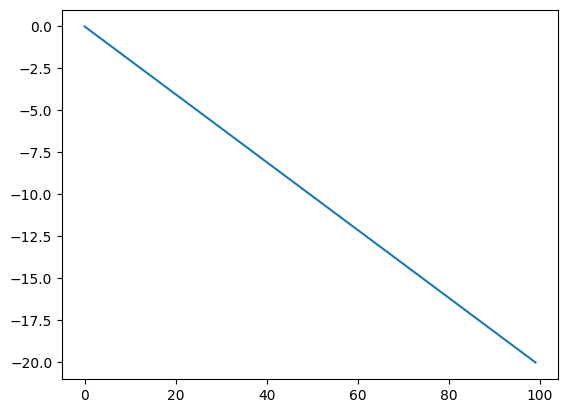

In [42]:
plt.plot(alphas)

In [2]:
import numpy as np

X = np.array([1, 2, 4, 5])

In [3]:
X

array([1, 2, 4, 5])

In [8]:
np.diff(X, prepend=X[0])

array([0, 1, 2, 1])

In [11]:
from joblib import Parallel, delayed
import time

# Function to square a number
def slow_function(x):
    """A function that takes a long time to run.

    For example, here we return x^2 after 2 seconds. In 
    practice this could be a slow running experiment.
    """
    time.sleep(2)
    return x ** 2

# List of numbers
numbers = [1, 2, 3]

# Sequential processing
start_time = time.time()
sequential_results = [slow_function(n) for n in numbers]
end_time = time.time()
print(f"Sequential processing took {end_time - start_time:.2f} seconds.")

# Parallel processing using joblib
start_time = time.time()
parallel_results = Parallel(n_jobs=-1)(delayed(slow_function)(n) for n in numbers)
end_time = time.time()
print(f"Parallel processing took {end_time - start_time:.2f} seconds.")

Sequential processing took 6.05 seconds.
Parallel processing took 2.06 seconds.


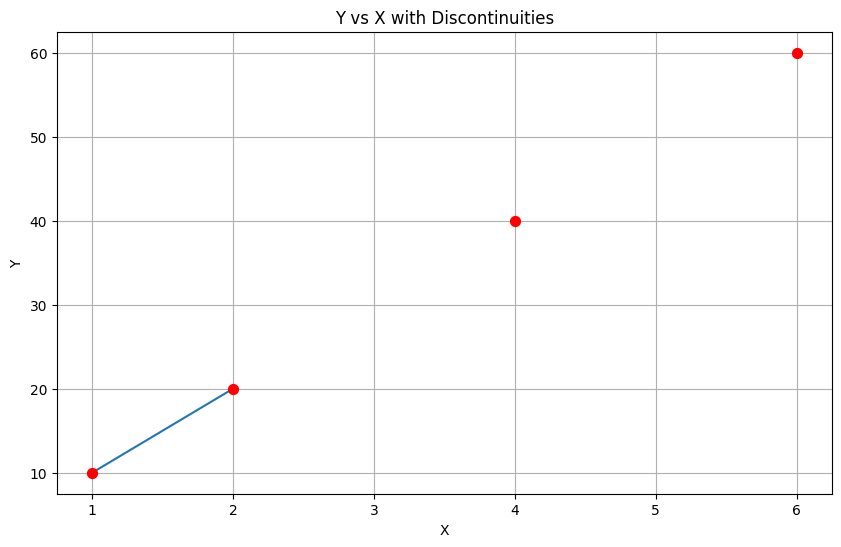

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([10, 20, np.nan, 40, np.nan, 60])

# Create the plot
plt.figure(figsize=(10, 6))

# Split the data into segments
segments = np.split(np.column_stack((x, y)), np.where(np.isnan(y))[0])

# Plot each segment
for segment in segments:
    if len(segment) > 0:
        seg_x = segment[:, 0]
        seg_y = segment[:, 1]
        
        # Plot the line segment
        plt.plot(seg_x, seg_y, '-')
        
        # Add scatter dots at the ends
        plt.scatter(seg_x[0], seg_y[0], color='red', s=50, zorder=5)
        plt.scatter(seg_x[-1], seg_y[-1], color='red', s=50, zorder=5)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Y vs X with Discontinuities')
plt.grid(True)
plt.show()